# Held-out test-set validation

This notebook replaces the archived checkpoint-validation notebook. Select one or more new experiment directories below; the saved `experiment_config.json` is loaded rather than retyped, so checkpoint architecture and held-out-data settings always match. All selected experiments must have identical configurations before their results can be compared.

It reconstructs final-stage replicas through the shared factory and evaluates them on the same untouched GTSRB test partition. Test predictions are used only in memory for supplemental bootstrap analysis and are not serialized. Do not use these results to tune training hyperparameters.

In [1]:
! git clone "https://github.com/ddimpfel/JHU_IS_26.git"

Cloning into 'JHU_IS_26'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 151 (delta 96), reused 120 (delta 65), pack-reused 0 (from 0)
Receiving objects: 100% (151/151), 33.92 MiB | 23.44 MiB/s, done.
Resolving deltas: 100% (96/96), done.


In [2]:
import os
os.chdir("/content/JHU_IS_26")
! pwd

/content/JHU_IS_26


In [3]:
! git rev-parse HEAD

95e52a096e668aca615221fe3af8587bdf2f9044


In [4]:
! pip install -q -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.9 MB/s eta 0:00:00


In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from init_experiment import (
    ExperimentConfig,
    add_model_component_columns,
    bootstrap_performance_diff,
    build_component_delta_table,
    build_gtsrb_data,
    evaluate_checkpoints,
    normalize_backbone_label,
    prepare_notebook_runtime,
    run_paired_component_tests,
    summarize_component_performance,
)

from google.colab import drive
drive.mount('/content/drive')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Add the exact experiment directories to validate. Each must contain
# `experiment_config.json`, `progress.json`, and final `models/` checkpoints.
RESULTS_NAMESPACE = 'test_validation'
EXPERIMENT_DIRS: list[Path] = [
    Path('/content/drive/MyDrive/is26_models/baseline_experiments/baseline_cil_protocol/'),
    # Path('/content/drive/MyDrive/is26_models/joint_embedding_experiments/joint_embedding_cil_protocol'),
]
CHECKPOINT_GLOB = '*__seed-*.pth'  # Final-stage replicas only.
BOOTSTRAP_RESAMPLES = 5000

runtime = prepare_notebook_runtime(RESULTS_NAMESPACE)
if not EXPERIMENT_DIRS:
    raise ValueError(
        'Set EXPERIMENT_DIRS to one or more new experiment directories before evaluating checkpoints.'
    )

experiment_dirs: list[Path] = [
    (path if path.is_absolute() else runtime.project_dir / path).resolve()
    for path in EXPERIMENT_DIRS
]
config_paths = [path / 'experiment_config.json' for path in experiment_dirs]
missing_configs = [path for path in config_paths if not path.is_file()]
if missing_configs:
    raise FileNotFoundError(f'Missing experiment configuration(s): {missing_configs}')

configs = [ExperimentConfig.load(path) for path in config_paths]
config = configs[0]
if any(candidate.to_dict() != config.to_dict() for candidate in configs[1:]):
    raise ValueError('All selected experiment directories must use identical ExperimentConfig values.')

rng = np.random.default_rng(seed=config.seed)

data = build_gtsrb_data(config)
MODELS_DIRS: list[Path] = [path / 'models' for path in experiment_dirs]
TEST_RESULTS_DIR = runtime.results_dir / 'test_results'
TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

display(pd.DataFrame([config.to_dict()]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


100%|██████████| 612M/612M [00:04<00:00, 145MB/s]

Extracting files...


,seed,run_seeds,cv_folds,cv_repeats,cv_epochs,final_run_seeds,throughput_warmup_batches,realtime_inference_samples_per_class,dataset_name,class_ids,...,lambda_aux,transformer_d_model,transformer_nhead,je_embedding_dim,je_projection_dim,je_feature_key,je_temperature,je_contrastive_weight,pretrained_backbones,device
0,7,"(7,)",3,1,8,"(7, 17, 27, 37)",3,25,meowmeowmeowmeowmeow/gtsrb-german-traffic-sign,"(1, 2, 3, 4, 5, 7, 8, 9, 10)",...,0.05,32,4,256,256,projections,0.07,0.1,True,None


In [8]:
checkpoint_paths = sorted(
    (checkpoint for models_dir in MODELS_DIRS for checkpoint in models_dir.glob(CHECKPOINT_GLOB)),
    key=lambda path: (path.parent.parent.name, path.name),
)
if not checkpoint_paths:
    raise FileNotFoundError(
        f'No checkpoints matching {CHECKPOINT_GLOB!r} were found in the selected experiment directories.'
    )

pd.DataFrame({
    'Experiment': [path.parent.parent.name for path in checkpoint_paths],
    'Checkpoint': [path.name for path in checkpoint_paths],
})

,Experiment,Checkpoint
0,baseline_cil_protocol,ConvNeXt Tiny + MLP Router + MLP Experts__seed...
1,baseline_cil_protocol,ConvNeXt Tiny + MLP Router + MLP Experts__seed...
2,baseline_cil_protocol,ConvNeXt Tiny + MLP Router + MLP Experts__seed...
3,baseline_cil_protocol,ConvNeXt Tiny + MLP Router + MLP Experts__seed...
4,baseline_cil_protocol,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...
...,...,...
91,baseline_cil_protocol,MobileNet Large + Regression Router + ResMLP E...
92,baseline_cil_protocol,MobileNet Large + Regression Router + Transfor...
93,baseline_cil_protocol,MobileNet Large + Regression Router + Transfor...
94,baseline_cil_protocol,MobileNet Large + Regression Router + Transfor...


In [9]:
test_results_df, model_preds, all_targets = evaluate_checkpoints(checkpoint_paths, data, TEST_RESULTS_DIR)
test_results_df = add_model_component_columns(test_results_df)
test_results_df['Backbone Group'] = test_results_df['Generalist'].map(normalize_backbone_label)
test_results_df['Joint Embedding'] = test_results_df['Backbone Group'].str.startswith('JE ').map({True: 'JE', False: 'No JE'})

summary_columns = [
    'Model', 'Final Seed', 'Backbone Group', 'Router', 'Expert', 'Test Loss',
    'Test Macro F1', 'Test Micro F1', 'Test Weighted F1',
    'Test ECE', 'Test Router Entropy', 'Test Expected Expert Calls',
    'Test Cost Proxy', 'Num Parameters',
]
summary_df = test_results_df.loc[:, [column for column in summary_columns if column in test_results_df.columns]]

Evaluating ConvNeXt Tiny + MLP Router + MLP Experts__seed-17...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 168MB/s] 


Evaluating ConvNeXt Tiny + MLP Router + MLP Experts__seed-27...
Evaluating ConvNeXt Tiny + MLP Router + MLP Experts__seed-37...
Evaluating ConvNeXt Tiny + MLP Router + MLP Experts__seed-7...
Evaluating ConvNeXt Tiny + MLP Router + ResMLP Experts__seed-17...
Evaluating ConvNeXt Tiny + MLP Router + ResMLP Experts__seed-27...
Evaluating ConvNeXt Tiny + MLP Router + ResMLP Experts__seed-37...
Evaluating ConvNeXt Tiny + MLP Router + ResMLP Experts__seed-7...
Evaluating ConvNeXt Tiny + MLP Router + Transformer Experts__seed-17...
Evaluating ConvNeXt Tiny + MLP Router + Transformer Experts__seed-27...
Evaluating ConvNeXt Tiny + MLP Router + Transformer Experts__seed-37...
Evaluating ConvNeXt Tiny + MLP Router + Transformer Experts__seed-7...
Evaluating ConvNeXt Tiny + Regression Router + MLP Experts__seed-17...
Evaluating ConvNeXt Tiny + Regression Router + MLP Experts__seed-27...
Evaluating ConvNeXt Tiny + Regression Router + MLP Experts__seed-37...
Evaluating ConvNeXt Tiny + Regression Rout

100%|██████████| 21.1M/21.1M [00:00<00:00, 172MB/s]


Evaluating JE MobileNet Large + MLP Router + MLP Experts__seed-27...
Evaluating JE MobileNet Large + MLP Router + MLP Experts__seed-37...
Evaluating JE MobileNet Large + MLP Router + MLP Experts__seed-7...
Evaluating JE MobileNet Large + MLP Router + ResMLP Experts__seed-17...
Evaluating JE MobileNet Large + MLP Router + ResMLP Experts__seed-27...
Evaluating JE MobileNet Large + MLP Router + ResMLP Experts__seed-37...
Evaluating JE MobileNet Large + MLP Router + ResMLP Experts__seed-7...
Evaluating JE MobileNet Large + MLP Router + Transformer Experts__seed-17...
Evaluating JE MobileNet Large + MLP Router + Transformer Experts__seed-27...
Evaluating JE MobileNet Large + MLP Router + Transformer Experts__seed-37...
Evaluating JE MobileNet Large + MLP Router + Transformer Experts__seed-7...
Evaluating JE MobileNet Large + Regression Router + MLP Experts__seed-17...
Evaluating JE MobileNet Large + Regression Router + MLP Experts__seed-27...
Evaluating JE MobileNet Large + Regression Route

,Model,Final Seed,Backbone Group,Router,Expert,Test Loss,Test Macro F1,Test Micro F1,Test Weighted F1,Test ECE,Test Router Entropy,Test Expected Expert Calls,Test Cost Proxy
0,JE ConvNeXt Tiny + Regression Router + Transfo...,7,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.059634,0.986346,0.987048,0.987033,0.011693,1.148436,2.0,28428283.0
1,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,17,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.079852,0.982690,0.984381,0.984270,0.015894,0.953346,2.0,28561403.0
2,JE ConvNeXt Tiny + Regression Router + ResMLP ...,7,JE ConvNeXt Tiny,Regression Router,ResMLP Experts,0.087291,0.981035,0.982286,0.982289,0.003388,1.381147,2.0,28354171.0
3,JE ConvNeXt Tiny + Regression Router + Transfo...,17,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.080655,0.980946,0.981714,0.981726,0.011532,1.227207,2.0,28428283.0
4,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,37,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.079821,0.981249,0.981524,0.981603,0.010567,1.163546,2.0,28561403.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,MobileNet Large + Regression Router + ResMLP E...,37,MobileNet Large,Regression Router,ResMLP Experts,0.324211,0.904935,0.902286,0.902498,0.030745,1.658350,2.0,3371677.0
92,MobileNet Large + MLP Router + ResMLP Experts,37,MobileNet Large,MLP Router,ResMLP Experts,0.341614,0.894008,0.894857,0.895071,0.037898,0.505580,2.0,5222557.0
93,MobileNet Large + MLP Router + Transformer Exp...,27,MobileNet Large,MLP Router,Transformer Experts,0.300459,0.896894,0.890095,0.892049,0.027812,0.471160,2.0,5115037.0
94,MobileNet Large + MLP Router + ResMLP Experts,7,MobileNet Large,MLP Router,ResMLP Experts,0.389780,0.880297,0.882476,0.883254,0.025995,0.265032,2.0,5222557.0


In [27]:
summary_df.sort_values(['Test Micro F1', 'Test Macro F1'], ascending=False).reset_index(drop=True)

,Model,Final Seed,Backbone Group,Router,Expert,Test Loss,Test Macro F1,Test Micro F1,Test Weighted F1,Test ECE,Test Router Entropy,Test Expected Expert Calls,Test Cost Proxy
0,JE ConvNeXt Tiny + Regression Router + Transfo...,7,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.059634,0.986346,0.987048,0.987033,0.011693,1.148436,2.0,28428283.0
1,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,17,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.079852,0.982690,0.984381,0.984270,0.015894,0.953346,2.0,28561403.0
2,JE ConvNeXt Tiny + Regression Router + ResMLP ...,7,JE ConvNeXt Tiny,Regression Router,ResMLP Experts,0.087291,0.981035,0.982286,0.982289,0.003388,1.381147,2.0,28354171.0
3,JE ConvNeXt Tiny + Regression Router + Transfo...,17,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.080655,0.980946,0.981714,0.981726,0.011532,1.227207,2.0,28428283.0
4,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,37,JE ConvNeXt Tiny,MLP Router,Transformer Experts,0.079821,0.981249,0.981524,0.981603,0.010567,1.163546,2.0,28561403.0
5,JE ConvNeXt Tiny + MLP Router + MLP Experts,37,JE ConvNeXt Tiny,MLP Router,MLP Experts,0.072387,0.981034,0.981524,0.981586,0.004757,1.411827,2.0,28353147.0
6,ConvNeXt Tiny + Regression Router + Transforme...,17,ConvNeXt Tiny,Regression Router,Transformer Experts,0.075289,0.981090,0.981333,0.981432,0.003343,1.727656,2.0,28109051.0
7,JE ConvNeXt Tiny + Regression Router + Transfo...,27,JE ConvNeXt Tiny,Regression Router,Transformer Experts,0.067722,0.980690,0.981143,0.981153,0.015737,1.078486,2.0,28428283.0
8,JE ConvNeXt Tiny + MLP Router + ResMLP Experts,7,JE ConvNeXt Tiny,MLP Router,ResMLP Experts,0.103691,0.979014,0.980190,0.980240,0.004836,1.203072,2.0,28487291.0
9,JE ConvNeXt Tiny + Regression Router + MLP Exp...,17,JE ConvNeXt Tiny,Regression Router,MLP Experts,0.069350,0.980514,0.980000,0.980180,0.005182,1.405666,2.0,28220027.0


In [14]:
test_metrics = [
    metric for metric in ['Test Macro F1', 'Test Micro F1', 'Test Weighted F1', 'Test ECE',
                          'Test Router Entropy', 'Test Cost Proxy', 'Num Parameters']
    if metric in test_results_df.columns
]
backbone_summary_df = summarize_component_performance(test_results_df, 'Backbone Group', test_metrics)
backbone_summary_df

,Backbone Group,Test Macro F1,Test Micro F1,Test Weighted F1,Test ECE,Test Router Entropy,Test Expected Expert Calls,Test Cost Proxy
0,JE ConvNeXt Tiny,0.972735,0.973294,0.973397,0.009130,1.227191,2.0,2.840072e+07
1,ConvNeXt Tiny,0.944201,0.946492,0.946504,0.014857,1.261989,2.0,2.869521e+07
2,JE MobileNet Large,0.932926,0.932635,0.932906,0.017533,1.349447,2.0,3.603232e+06
3,MobileNet Large,0.918633,0.916976,0.917531,0.024474,1.045221,2.0,4.215624e+06


,Router,Expert,Final Seed,Backbone Group,Test Macro F1 [MobileNet Large],Test Macro F1 [ConvNeXt Tiny],Test Macro F1 Delta (ConvNeXt Tiny - MobileNet Large),Test Micro F1 [MobileNet Large],Test Micro F1 [ConvNeXt Tiny],Test Micro F1 Delta (ConvNeXt Tiny - MobileNet Large),...,Test ECE [JE MobileNet Large],Test ECE Delta (JE MobileNet Large - MobileNet Large),Test Macro F1 [JE ConvNeXt Tiny],Test Macro F1 Delta (JE ConvNeXt Tiny - MobileNet Large),Test Micro F1 [JE ConvNeXt Tiny],Test Micro F1 Delta (JE ConvNeXt Tiny - MobileNet Large),Test Weighted F1 [JE ConvNeXt Tiny],Test Weighted F1 Delta (JE ConvNeXt Tiny - MobileNet Large),Test ECE [JE ConvNeXt Tiny],Test ECE Delta (JE ConvNeXt Tiny - MobileNet Large)
0,MLP Router,MLP Experts,7,ConvNeXt Tiny,0.927892,0.947441,0.019549,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MLP Router,MLP Experts,17,ConvNeXt Tiny,0.914617,0.954802,0.040185,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MLP Router,MLP Experts,27,ConvNeXt Tiny,0.907425,0.948516,0.041090,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MLP Router,MLP Experts,37,ConvNeXt Tiny,0.905286,0.905948,0.000662,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MLP Router,ResMLP Experts,7,ConvNeXt Tiny,0.880297,0.936684,0.056387,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,Regression Router,ResMLP Experts,37,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016868,-0.013877
284,Regression Router,Transformer Experts,7,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011693,-0.033081
285,Regression Router,Transformer Experts,17,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011532,-0.036532
286,Regression Router,Transformer Experts,27,JE ConvNeXt Tiny,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.015737,-0.020775


In [107]:
backbone_order = ['MobileNet Large', 'ConvNeXt Tiny', 'JE MobileNet Large', 'JE ConvNeXt Tiny']
available_backbones = set(test_results_df['Backbone Group'].dropna())
comparisons = [name for name in backbone_order if name in available_backbones]
paired_metrics = [metric for metric in ['Test Macro F1', 'Test ECE'] if metric in test_results_df.columns]


## Paired Backbone Significance Tests

`run_paired_component_tests` shows the Benjamani-Hochberg corrected p-values for comparison tests between the raw test dataset values of each model Backbone.

In [128]:
run_paired_component_tests(
    test_results_df,
    component='Backbone Group',
    baseline='MobileNet Large',
    comparisons=backbone_order,
    fixed_columns=['Router', 'Expert', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Backbone Group),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,ConvNeXt Tiny,MobileNet Large,Test ECE,24,0.014857,0.024474,-0.009618,-0.009292,0.018029,1.260483e-02,Wilcoxon signed-rank,1.512580e-02,True
1,ConvNeXt Tiny,MobileNet Large,Test Macro F1,24,0.944201,0.918633,0.025568,0.034378,0.031937,9.083748e-05,Wilcoxon signed-rank,1.614690e-04,True
2,JE ConvNeXt Tiny,MobileNet Large,Test ECE,24,0.009130,0.024474,-0.015344,-0.013919,0.010668,5.960464e-07,Wilcoxon signed-rank,1.788139e-06,True
3,JE ConvNeXt Tiny,MobileNet Large,Test Macro F1,24,0.972735,0.918633,0.054102,0.050792,0.017758,1.192093e-07,Wilcoxon signed-rank,7.152557e-07,True
4,JE MobileNet Large,MobileNet Large,Test ECE,24,0.017533,0.024474,-0.006942,-0.005981,0.016659,7.379258e-02,Wilcoxon signed-rank,7.379258e-02,False
5,JE MobileNet Large,MobileNet Large,Test Macro F1,24,0.932926,0.918633,0.014293,0.011219,0.014739,1.076460e-04,Wilcoxon signed-rank,1.614690e-04,True


In [127]:
run_paired_component_tests(
    test_results_df,
    component='Backbone Group',
    baseline='ConvNeXt Tiny',
    comparisons=backbone_order,
    fixed_columns=['Router', 'Expert', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Backbone Group),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,JE ConvNeXt Tiny,ConvNeXt Tiny,Test ECE,24,0.009130,0.014857,-0.005727,-0.005430,0.011502,0.015045,Wilcoxon signed-rank,0.018054,True
1,JE ConvNeXt Tiny,ConvNeXt Tiny,Test Macro F1,24,0.972735,0.944201,0.028534,0.022357,0.029472,0.000008,Wilcoxon signed-rank,0.000050,True
2,JE MobileNet Large,ConvNeXt Tiny,Test ECE,24,0.017533,0.014857,0.002676,0.003054,0.013397,0.113961,Wilcoxon signed-rank,0.113961,False
3,JE MobileNet Large,ConvNeXt Tiny,Test Macro F1,24,0.932926,0.944201,-0.011274,-0.017000,0.027618,0.003901,Wilcoxon signed-rank,0.007801,True
4,MobileNet Large,ConvNeXt Tiny,Test ECE,24,0.024474,0.014857,0.009618,0.009292,0.018029,0.012605,Wilcoxon signed-rank,0.018054,True
5,MobileNet Large,ConvNeXt Tiny,Test Macro F1,24,0.918633,0.944201,-0.025568,-0.034378,0.031937,0.000091,Wilcoxon signed-rank,0.000273,True


In [126]:
run_paired_component_tests(
    test_results_df,
    component='Backbone Group',
    baseline='JE MobileNet Large',
    comparisons=backbone_order,
    fixed_columns=['Router', 'Expert', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Backbone Group),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,ConvNeXt Tiny,JE MobileNet Large,Test ECE,24,0.014857,0.017533,-0.002676,-0.003054,0.013397,1.139612e-01,Wilcoxon signed-rank,1.139612e-01,False
1,ConvNeXt Tiny,JE MobileNet Large,Test Macro F1,24,0.944201,0.932926,0.011274,0.017000,0.027618,3.900647e-03,Wilcoxon signed-rank,5.850971e-03,True
2,JE ConvNeXt Tiny,JE MobileNet Large,Test ECE,24,0.009130,0.017533,-0.008402,-0.007409,0.011430,1.579642e-03,Wilcoxon signed-rank,3.159285e-03,True
3,JE ConvNeXt Tiny,JE MobileNet Large,Test Macro F1,24,0.972735,0.932926,0.039808,0.039437,0.013286,1.192093e-07,Wilcoxon signed-rank,7.152557e-07,True
4,MobileNet Large,JE MobileNet Large,Test ECE,24,0.024474,0.017533,0.006942,0.005981,0.016659,7.379258e-02,Wilcoxon signed-rank,8.855109e-02,False
5,MobileNet Large,JE MobileNet Large,Test Macro F1,24,0.918633,0.932926,-0.014293,-0.011219,0.014739,1.076460e-04,Wilcoxon signed-rank,3.229380e-04,True


In [125]:
run_paired_component_tests(
    test_results_df,
    component='Backbone Group',
    baseline='JE ConvNeXt Tiny',
    comparisons=backbone_order,
    fixed_columns=['Router', 'Expert', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Backbone Group),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,ConvNeXt Tiny,JE ConvNeXt Tiny,Test ECE,24,0.014857,0.009130,0.005727,0.005430,0.011502,1.504493e-02,Wilcoxon signed-rank,1.504493e-02,True
1,ConvNeXt Tiny,JE ConvNeXt Tiny,Test Macro F1,24,0.944201,0.972735,-0.028534,-0.022357,0.029472,8.344650e-06,Wilcoxon signed-rank,1.251698e-05,True
2,JE MobileNet Large,JE ConvNeXt Tiny,Test ECE,24,0.017533,0.009130,0.008402,0.007409,0.011430,1.579642e-03,Wilcoxon signed-rank,1.895571e-03,True
3,JE MobileNet Large,JE ConvNeXt Tiny,Test Macro F1,24,0.932926,0.972735,-0.039808,-0.039437,0.013286,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True
4,MobileNet Large,JE ConvNeXt Tiny,Test ECE,24,0.024474,0.009130,0.015344,0.013919,0.010668,5.960464e-07,Wilcoxon signed-rank,1.192093e-06,True
5,MobileNet Large,JE ConvNeXt Tiny,Test Macro F1,24,0.918633,0.972735,-0.054102,-0.050792,0.017758,1.192093e-07,Wilcoxon signed-rank,3.576279e-07,True


In [11]:
if len(model_preds) >= 2 and all_targets is not None:

    bootstrap_results, bootstrap_model_performance = (
        bootstrap_performance_diff(
            all_targets=all_targets,
            model_preds=model_preds,
            rng=rng,
            resamples=BOOTSTRAP_RESAMPLES,
            average="macro",
            stratified=True,
        )
    )

    bootstrap_model_performance_df = pd.DataFrame(
        bootstrap_model_performance
    ).sort_values(
        "Observed F1",
        ascending=False,
    ).reset_index(drop=True)

    bootstrap_results_df = pd.DataFrame(
        bootstrap_results
    ).sort_values(
        "Observed Delta (A-B)",
        key=lambda values: values.abs(),
        ascending=False,
    ).reset_index(drop=True)
else:
    print('At least two successfully reconstructed checkpoints are required for pairwise bootstrap comparisons.')

Per-model held-out Macro-F1 uncertainty:


,Model,Observed F1,Bootstrap Mean F1,Bootstrap Std F1,95% CI Lower,95% CI Upper,F1 Average,Bootstrap Resamples
0,JE ConvNeXt Tiny + Regression Router + Transfo...,0.986346,0.986336,0.001633,0.983045,0.989472,macro,5000
1,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,0.982690,0.982666,0.001876,0.978915,0.986234,macro,5000
2,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,0.981249,0.981242,0.001873,0.977500,0.984775,macro,5000
3,ConvNeXt Tiny + Regression Router + Transforme...,0.981090,0.981104,0.001886,0.977413,0.984685,macro,5000
4,JE ConvNeXt Tiny + Regression Router + ResMLP ...,0.981035,0.981058,0.001921,0.977201,0.984757,macro,5000
...,...,...,...,...,...,...,...,...
91,MobileNet Large + Regression Router + ResMLP E...,0.904935,0.904879,0.003853,0.897381,0.912453,macro,5000
92,MobileNet Large + MLP Router + Transformer Exp...,0.896894,0.896802,0.003852,0.889469,0.904265,macro,5000
93,MobileNet Large + MLP Router + ResMLP Experts_...,0.894008,0.893907,0.004080,0.885939,0.901652,macro,5000
94,MobileNet Large + MLP Router + ResMLP Experts_...,0.880297,0.880252,0.004322,0.871534,0.888585,macro,5000


Paired model differences:


,Model A,Model B,Observed Delta (A-B),Bootstrap Mean Delta,95% CI Lower,95% CI Upper,Bootstrap Tail Probability,F1 Average,Bootstrap Resamples,FDR-BH Adjusted Tail Probability,95% CI Excludes Zero
0,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + Regression Router + Transfo...,-0.158886,-0.158933,-0.168085,-0.149835,0.000400,macro,5000,0.000536,True
1,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,-0.155230,-0.155263,-0.164395,-0.145881,0.000400,macro,5000,0.000536,True
2,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,-0.153789,-0.153839,-0.163248,-0.144554,0.000400,macro,5000,0.000536,True
3,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,ConvNeXt Tiny + Regression Router + Transforme...,-0.153630,-0.153700,-0.163131,-0.144468,0.000400,macro,5000,0.000536,True
4,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + Regression Router + ResMLP ...,-0.153575,-0.153655,-0.163051,-0.144325,0.000400,macro,5000,0.000536,True
...,...,...,...,...,...,...,...,...,...,...,...
4555,ConvNeXt Tiny + Regression Router + ResMLP Exp...,ConvNeXt Tiny + Regression Router + Transforme...,-0.000064,-0.000064,-0.005647,0.005282,0.989402,macro,5000,0.990053,False
4556,ConvNeXt Tiny + Regression Router + Transforme...,JE ConvNeXt Tiny + MLP Router + MLP Experts__s...,0.000056,0.000053,-0.003448,0.003546,0.966607,macro,5000,0.969370,False
4557,ConvNeXt Tiny + Regression Router + Transforme...,JE ConvNeXt Tiny + Regression Router + ResMLP ...,0.000055,0.000046,-0.003612,0.003516,0.986603,macro,5000,0.987686,False
4558,JE MobileNet Large + Regression Router + ResML...,MobileNet Large + Regression Router + Transfor...,-0.000038,-0.000040,-0.007184,0.006970,0.992202,macro,5000,0.992637,False


### Bootstrap Performance Uncertainty
This table shows the 95% Confidence Intervals for the `Test Macro F1` of each individual model configuration, calculated using bootstrap resampling. This helps us understand the variance in expected performance on unseen data.

In [29]:
print("Per-model held-out Macro-F1 uncertainty:")
display(bootstrap_model_performance_df)

Per-model held-out Macro-F1 uncertainty:


,Model,Observed F1,Bootstrap Mean F1,Bootstrap Std F1,95% CI Lower,95% CI Upper,F1 Average,Bootstrap Resamples
0,JE ConvNeXt Tiny + Regression Router + Transfo...,0.986346,0.986336,0.001633,0.983045,0.989472,macro,5000
1,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,0.982690,0.982666,0.001876,0.978915,0.986234,macro,5000
2,JE ConvNeXt Tiny + MLP Router + Transformer Ex...,0.981249,0.981242,0.001873,0.977500,0.984775,macro,5000
3,ConvNeXt Tiny + Regression Router + Transforme...,0.981090,0.981104,0.001886,0.977413,0.984685,macro,5000
4,JE ConvNeXt Tiny + Regression Router + ResMLP ...,0.981035,0.981058,0.001921,0.977201,0.984757,macro,5000
5,JE ConvNeXt Tiny + MLP Router + MLP Experts__s...,0.981034,0.981051,0.001898,0.977310,0.984645,macro,5000
6,JE ConvNeXt Tiny + Regression Router + Transfo...,0.980946,0.980955,0.001926,0.977208,0.984628,macro,5000
7,JE ConvNeXt Tiny + Regression Router + Transfo...,0.980690,0.980686,0.001902,0.976937,0.984311,macro,5000
8,JE ConvNeXt Tiny + Regression Router + MLP Exp...,0.980514,0.980511,0.001843,0.976779,0.983956,macro,5000
9,JE ConvNeXt Tiny + MLP Router + ResMLP Experts...,0.979014,0.979047,0.001989,0.975095,0.982841,macro,5000


### Pairwise Bootstrap Comparisons (Joint Embedding vs Baseline)
This table compares models that have identical configurations except for whether they use a standard backbone or a Joint Embedding (JE) backbone. It shows if the difference in `Test Macro F1` is statistically significant based on bootstrap testing.

In [112]:
is_je_a = bootstrap_results_df['Model A'].str.startswith('JE ')
is_je_b = bootstrap_results_df['Model B'].str.startswith('JE ')

base_a = bootstrap_results_df['Model A'].str.replace('^JE ', '', regex=True)
base_b = bootstrap_results_df['Model B'].str.replace('^JE ', '', regex=True)

je_vs_non_je_mask = (base_a == base_b) & (is_je_a != is_je_b)
je_comparison_df = bootstrap_results_df[je_vs_non_je_mask].reset_index(drop=True)

print("Paired model differences (JE vs Non-JE for identical configurations):")
je_comparison_df

Paired model differences (JE vs Non-JE for identical configurations):


,Model A,Model B,Observed Delta (A-B),Bootstrap Mean Delta,95% CI Lower,95% CI Upper,Bootstrap Tail Probability,F1 Average,Bootstrap Resamples,FDR-BH Adjusted Tail Probability,95% CI Excludes Zero
0,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + MLP Router + ResMLP Experts...,-0.139309,-0.139303,-0.148759,-0.129908,0.000400,macro,5000,0.000536,True
1,ConvNeXt Tiny + MLP Router + MLP Experts__seed-37,JE ConvNeXt Tiny + MLP Router + MLP Experts__s...,-0.075086,-0.075124,-0.082705,-0.067835,0.000400,macro,5000,0.000536,True
2,JE MobileNet Large + MLP Router + Transformer ...,MobileNet Large + MLP Router + Transformer Exp...,0.045509,0.045568,0.038024,0.052884,0.000400,macro,5000,0.000536,True
3,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + MLP Router + ResMLP Experts...,-0.042329,-0.042342,-0.048626,-0.036273,0.000400,macro,5000,0.000536,True
4,ConvNeXt Tiny + Regression Router + MLP Expert...,JE ConvNeXt Tiny + Regression Router + MLP Exp...,-0.039957,-0.039976,-0.046426,-0.033820,0.000400,macro,5000,0.000536,True
5,ConvNeXt Tiny + Regression Router + ResMLP Exp...,JE ConvNeXt Tiny + Regression Router + ResMLP ...,-0.038837,-0.038811,-0.045603,-0.032048,0.000400,macro,5000,0.000536,True
6,ConvNeXt Tiny + MLP Router + ResMLP Experts__s...,JE ConvNeXt Tiny + MLP Router + ResMLP Experts...,-0.038401,-0.038438,-0.044726,-0.032246,0.000400,macro,5000,0.000536,True
7,JE MobileNet Large + MLP Router + Transformer ...,MobileNet Large + MLP Router + Transformer Exp...,0.037805,0.037886,0.030457,0.045331,0.000400,macro,5000,0.000536,True
8,ConvNeXt Tiny + Regression Router + MLP Expert...,JE ConvNeXt Tiny + Regression Router + MLP Exp...,-0.035754,-0.035815,-0.042460,-0.029311,0.000400,macro,5000,0.000536,True
9,JE MobileNet Large + MLP Router + ResMLP Exper...,MobileNet Large + MLP Router + ResMLP Experts_...,0.035268,0.035248,0.026330,0.044299,0.000400,macro,5000,0.000536,True


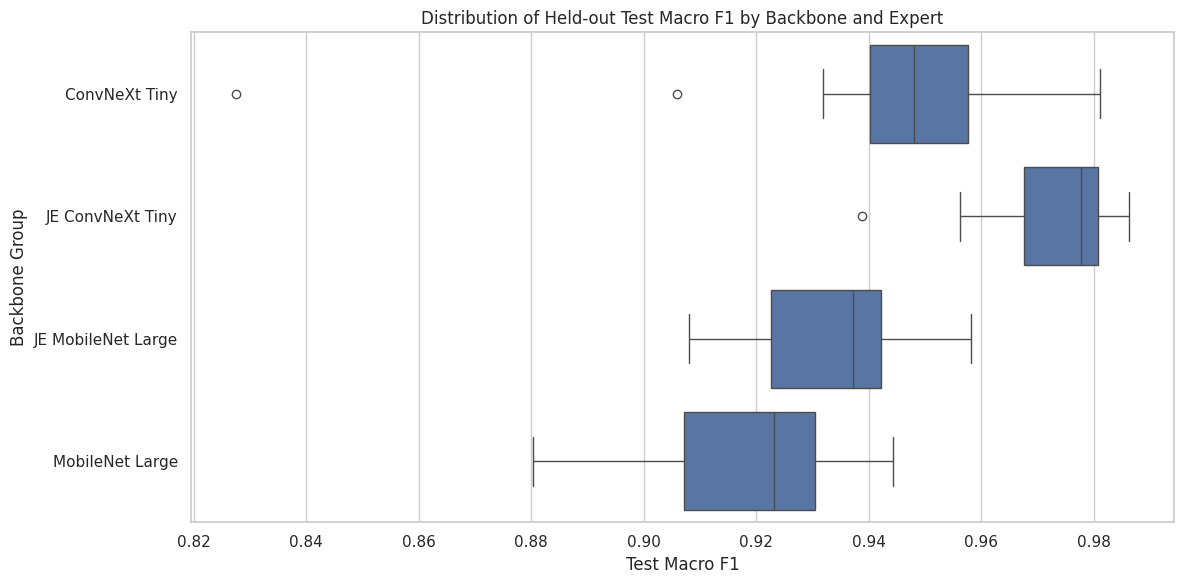

In [78]:
if {'Test Macro F1', 'Backbone Group'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Test Macro F1', y='Backbone Group')
    plt.title('Distribution of Held-out Test Macro F1 by Backbone and Expert')
    plt.tight_layout()
    plt.show()

### Held-out Performance Distributions
The following visualizations show the distribution of `Test Macro F1` scores grouped by different model components. This allows us to see how much the choice of Backbone, Router, or Expert impacts the variance and median of the final accuracy.

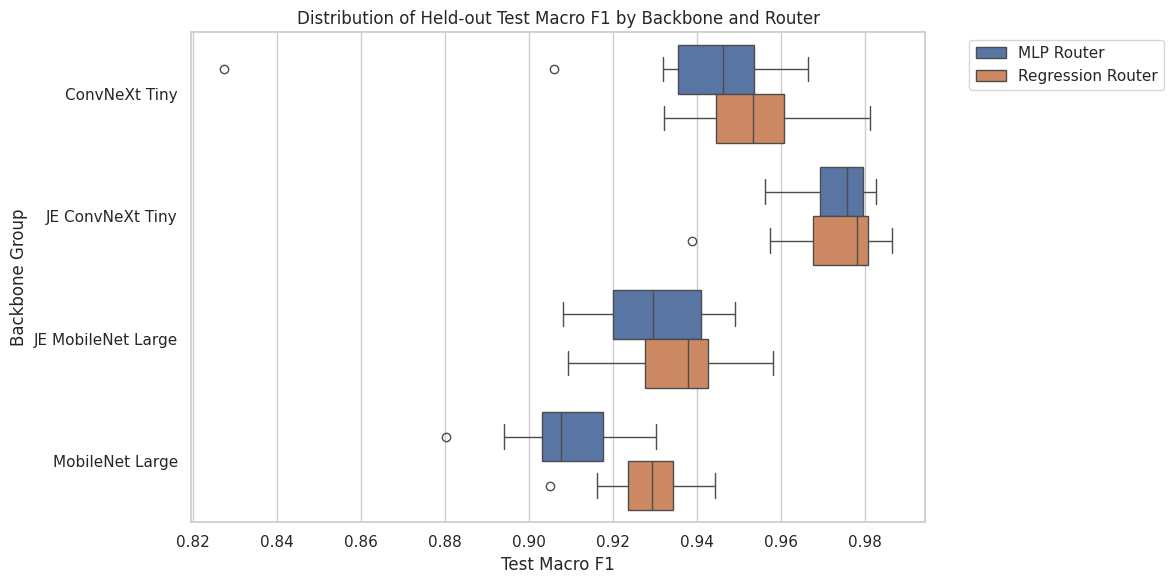

In [81]:
if {'Test Macro F1', 'Backbone Group', 'Router'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Test Macro F1', y='Backbone Group', hue='Router')
    plt.title('Distribution of Held-out Test Macro F1 by Backbone and Router')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

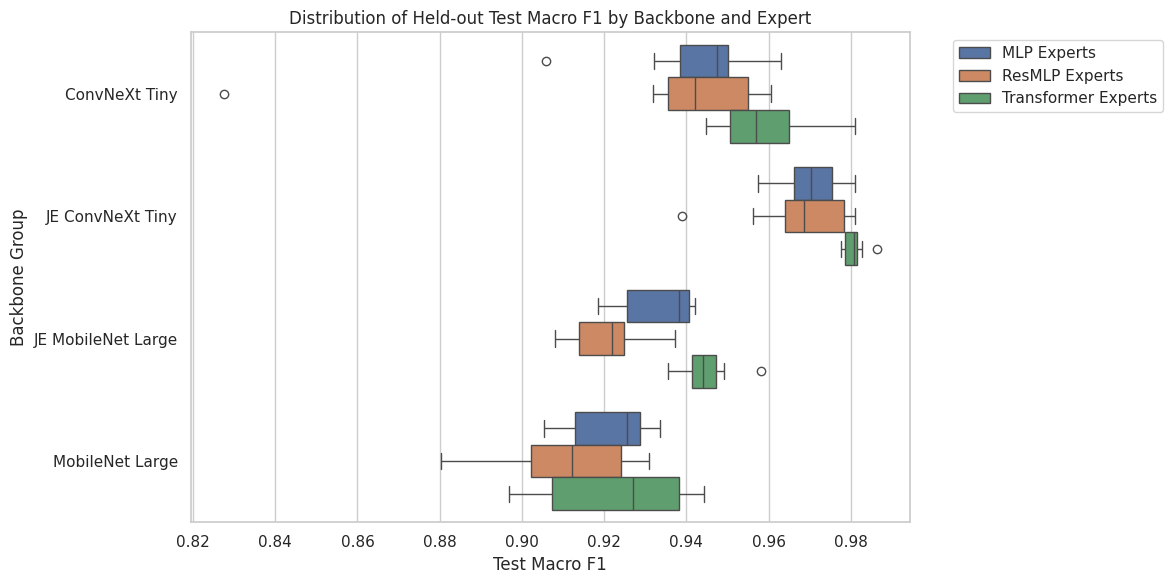

In [82]:
if {'Test Macro F1', 'Backbone Group', 'Expert'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Test Macro F1', y='Backbone Group', hue='Expert')
    plt.title('Distribution of Held-out Test Macro F1 by Backbone and Expert')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

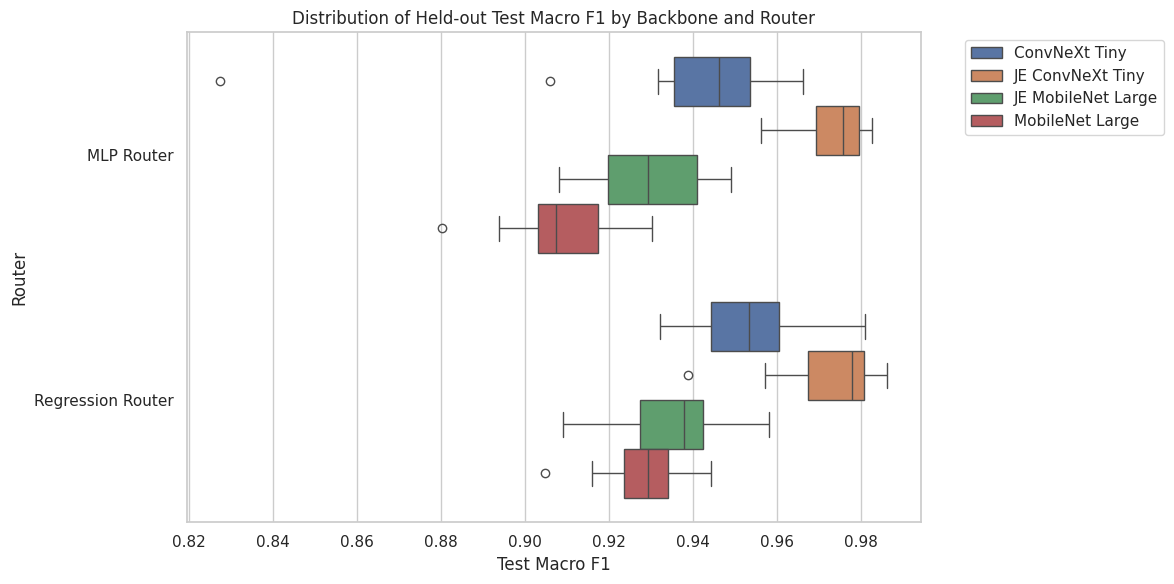

In [83]:
if {'Test Macro F1', 'Backbone Group', 'Router'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Test Macro F1', y='Router', hue='Backbone Group')
    plt.title('Distribution of Held-out Test Macro F1 by Backbone and Router')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

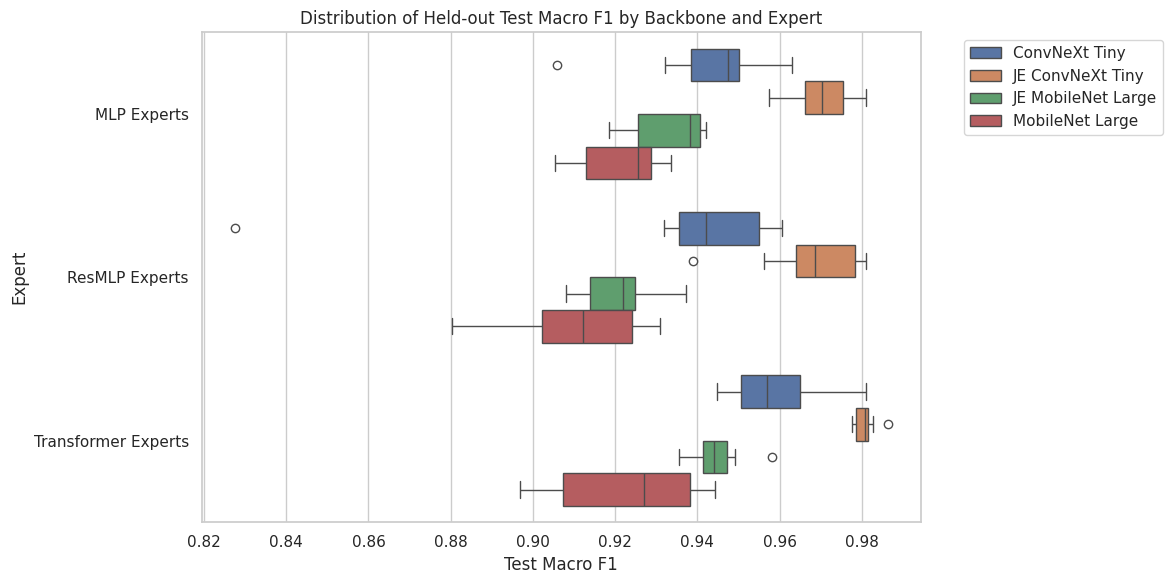

In [84]:
if {'Test Macro F1', 'Backbone Group', 'Expert'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Test Macro F1', y='Expert', hue='Backbone Group')
    plt.title('Distribution of Held-out Test Macro F1 by Backbone and Expert')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

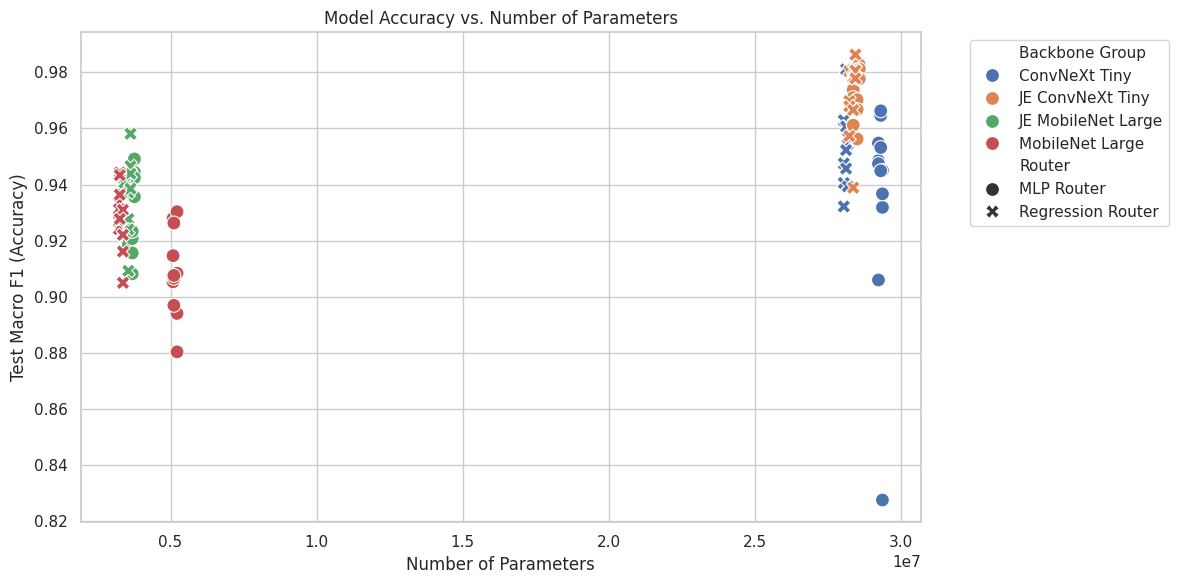

In [85]:
if {'Test Macro F1', 'Test Cost Proxy', 'Backbone Group'}.issubset(test_results_df.columns):
    # Plot 2: Scatter plot of Accuracy vs. Parameters
    plt.figure(figsize=(12, 6))
    sns.scatterplot(
        data=test_results_df,
        x='Test Cost Proxy',
        y='Test Macro F1',
        hue='Backbone Group',
        style='Router',
        s=100
    )
    plt.title('Model Accuracy vs. Number of Parameters')
    plt.xlabel('Number of Parameters')
    plt.ylabel('Test Macro F1 (Accuracy)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [90]:
def plot_delta_histogram(delta_df, metric_to_plot, comparison_models=None):
    delta_columns = [col for col in delta_df.columns if metric_to_plot in col and 'Delta' in col]

    if not delta_columns:
        print(f"No delta columns found for metric '{metric_to_plot}' in the provided dataframe.")
        return

    plt.figure(figsize=(10, 6))

    plot_data = []
    for col in delta_columns:
        try:
            comparison_name = col.split('(')[1].split(' - ')[0]
        except IndexError:
            continue
        if comparison_models and comparison_name not in comparison_models:
            continue

        temp_df = delta_df[['Router', 'Expert', 'Final Seed', col]].copy()
        temp_df = temp_df.rename(columns={col: 'Delta'})
        temp_df['Comparison Model'] = comparison_name
        plot_data.append(temp_df)

    if not plot_data:
        print(f"No data found matching the specified comparison models: {comparison_models}")
        plt.close()
        return

    melted_df = pd.concat(plot_data, ignore_index=True).dropna(subset=['Delta'])
    sns.histplot(
        data=melted_df,
        x='Delta',
        hue='Comparison Model',
        kde=True,
        element='step',
        alpha=0.5,
        bins=15
    )
    plt.title(f'Distribution of Paired Differences ({metric_to_plot})')
    plt.grid(False)
    plt.xlabel(f'Delta ({metric_to_plot})')
    plt.ylabel('Frequency')
    plt.axvline(0, color='black', linestyle='--', linewidth=1.5)
    plt.tight_layout()
    plt.show()

### Paired Difference (Delta) Distributions
The histograms below visualize the distribution of the pairwise differences (`Delta`) in `Test Macro F1` when changing one component while keeping the others fixed. A distribution shifted to the right of the zero-line indicates the Comparison model generally outperforms the Baseline model.

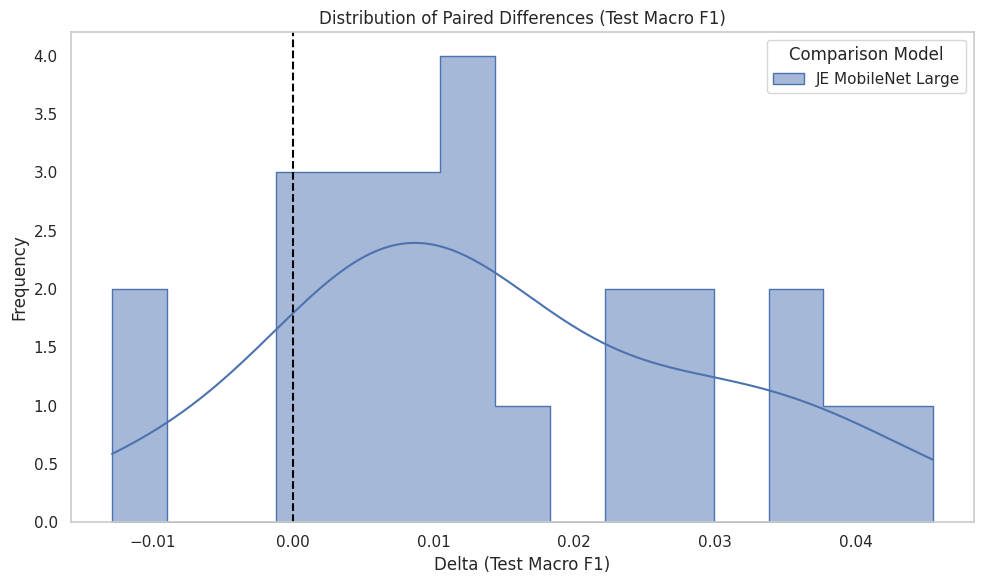

In [91]:
mn_comparisons = [name for name in comparisons if name != 'MobileNet Large']
mn_backbone_delta_df = build_component_delta_table(
    test_results_df, 'Backbone Group', 'MobileNet Large', mn_comparisons, ['Router', 'Expert', 'Final Seed'], paired_metrics
)
plot_delta_histogram(mn_backbone_delta_df, 'Test Macro F1', comparison_models=['JE MobileNet Large'])

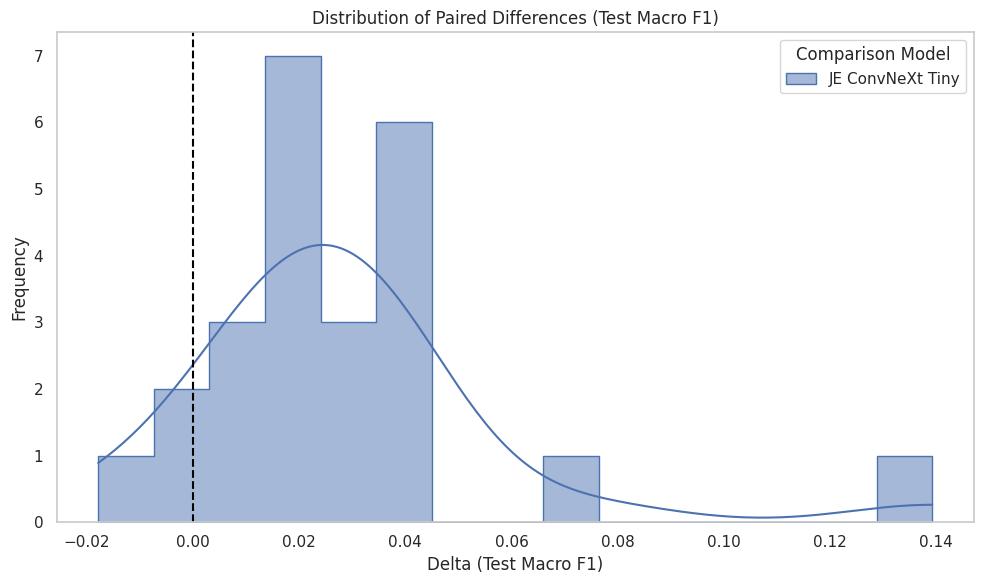

In [87]:
cn_comparisons = [name for name in comparisons if name != 'ConvNeXt Tiny']
cn_backbone_delta_df = build_component_delta_table(
    test_results_df, 'Backbone Group', 'ConvNeXt Tiny', cn_comparisons, ['Router', 'Expert', 'Final Seed'], paired_metrics
)
plot_delta_histogram(cn_backbone_delta_df, 'Test Macro F1', comparison_models=['JE ConvNeXt Tiny'])

### Component Significance: Router and Expert
In addition to the backbone, we want to know if the choice of Router or Expert has a statistically significant impact on performance.

In [124]:
available_routers = set(test_results_df['Router'].dropna())
router_order = ['MLP Router', 'Regression Router']
valid_routers = [r for r in router_order if r in available_routers]
run_paired_component_tests(
    test_results_df,
    component='Router',
    baseline='MLP Router',
    comparisons=valid_routers,
    fixed_columns=['Backbone Group', 'Expert', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Router),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,Regression Router,MLP Router,Test ECE,48,0.016077,0.01692,-0.000843,-0.002092,0.010106,0.518244,Wilcoxon signed-rank,0.518244,False
1,Regression Router,MLP Router,Test Macro F1,48,0.947377,0.93687,0.010507,0.007711,0.022521,0.001234,Wilcoxon signed-rank,0.002467,True


In [120]:
available_experts = set(test_results_df['Expert'].dropna())
expert_order = ['MLP Experts', 'ResMLP Experts', 'Transformer Experts']
valid_experts = [e for e in expert_order if e in available_experts]
run_paired_component_tests(
    test_results_df,
    component='Expert',
    baseline='MLP Experts',
    comparisons=valid_experts,
    fixed_columns=['Backbone Group', 'Router', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Expert),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,ResMLP Experts,MLP Experts,Test ECE,32,0.018817,0.011790,0.007027,0.003382,0.011257,0.000398,Wilcoxon signed-rank,0.001592,True
1,ResMLP Experts,MLP Experts,Test Macro F1,32,0.932557,0.941859,-0.009302,-0.005241,0.026992,0.026595,Wilcoxon signed-rank,0.026595,True
2,Transformer Experts,MLP Experts,Test ECE,32,0.018889,0.011790,0.007099,0.005222,0.013445,0.009340,Wilcoxon signed-rank,0.012453,True
3,Transformer Experts,MLP Experts,Test Macro F1,32,0.951956,0.941859,0.010097,0.009069,0.015043,0.000837,Wilcoxon signed-rank,0.001674,True


In [121]:
available_experts = set(test_results_df['Expert'].dropna())
expert_order = ['MLP Experts', 'ResMLP Experts', 'Transformer Experts']
valid_experts = [e for e in expert_order if e in available_experts]
run_paired_component_tests(
    test_results_df,
    component='Expert',
    baseline='Transformer Experts',
    comparisons=valid_experts,
    fixed_columns=['Backbone Group', 'Router', 'Final Seed'],
    metrics=paired_metrics
)

,Comparison (Expert),Baseline,Metric,Paired Configurations,Comparison Mean,Baseline Mean,Mean Delta (Comparison - Baseline),Median Delta,Std Delta,Raw P Value,Test,FDR BH P Value,Significant @ 0.05
0,MLP Experts,Transformer Experts,Test ECE,32,0.011790,0.018889,-0.007099,-0.005222,0.013445,0.009340,Wilcoxon signed-rank,0.012453,True
1,MLP Experts,Transformer Experts,Test Macro F1,32,0.941859,0.951956,-0.010097,-0.009069,0.015043,0.000837,Wilcoxon signed-rank,0.001674,True
2,ResMLP Experts,Transformer Experts,Test ECE,32,0.018817,0.018889,-0.000072,-0.002588,0.016606,0.664522,Wilcoxon signed-rank,0.664522,False
3,ResMLP Experts,Transformer Experts,Test Macro F1,32,0.932557,0.951956,-0.019399,-0.017891,0.023978,0.000005,Wilcoxon signed-rank,0.000018,True


### Component Interaction Heatmap
Visualizing the average performance across combinations of architectural choices to identify the best synergies.

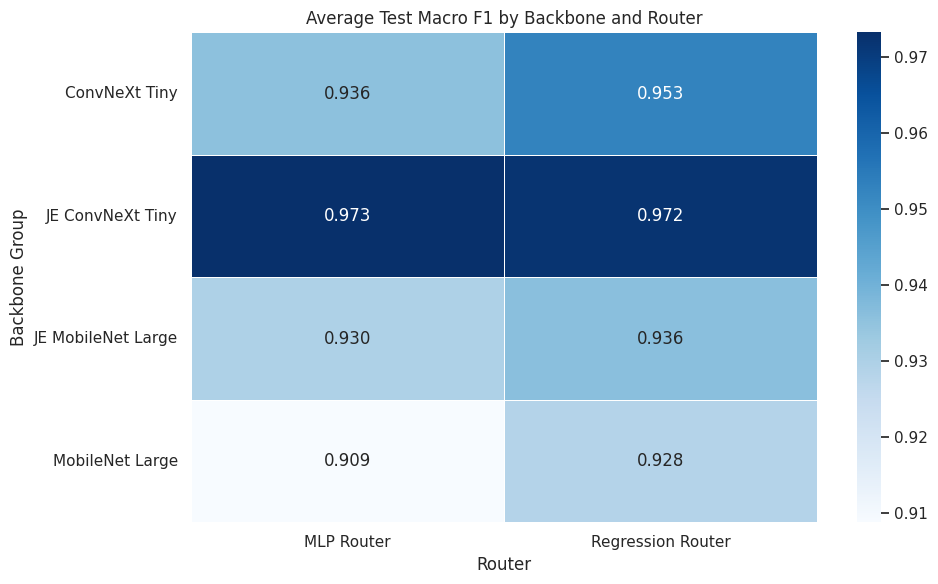

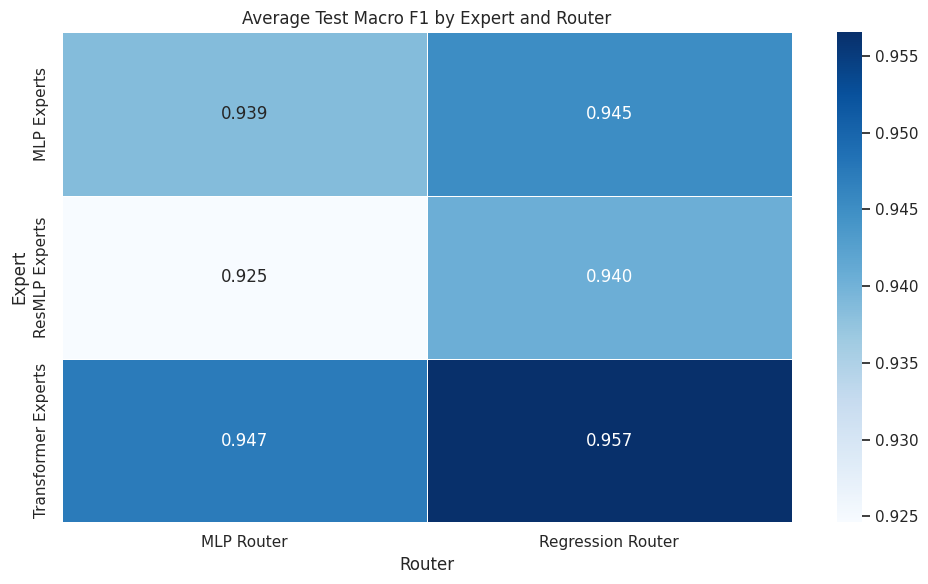

In [133]:
if {'Test Macro F1', 'Backbone Group', 'Router'}.issubset(test_results_df.columns):
    plt.figure(figsize=(10, 6))
    pivot_f1 = test_results_df.pivot_table(
        values='Test Macro F1',
        index='Backbone Group',
        columns='Router',
        aggfunc='mean'
    )
    sns.heatmap(pivot_f1, annot=True, cmap='Blues', fmt=".3f", linewidths=.5)
    plt.title('Average Test Macro F1 by Backbone and Router')
    plt.tight_layout()
    plt.show()

if {'Test Macro F1', 'Router', 'Expert'}.issubset(test_results_df.columns):
    plt.figure(figsize=(10, 6))
    pivot_f1_expert = test_results_df.pivot_table(
        values='Test Macro F1',
        index='Expert',
        columns='Router',
        aggfunc='mean'
    )
    sns.heatmap(pivot_f1_expert, annot=True, cmap='Blues', fmt=".3f", linewidths=.5)
    plt.title('Average Test Macro F1 by Expert and Router')
    plt.tight_layout()
    plt.show()

### Router Behavior Analysis
Analyzing `Test Router Entropy` to understand how differently the routing mechanisms distribute inputs among experts. Lower entropy indicates a more decisive, sparse routing behavior, while higher entropy indicates the router is spreading the load evenly.

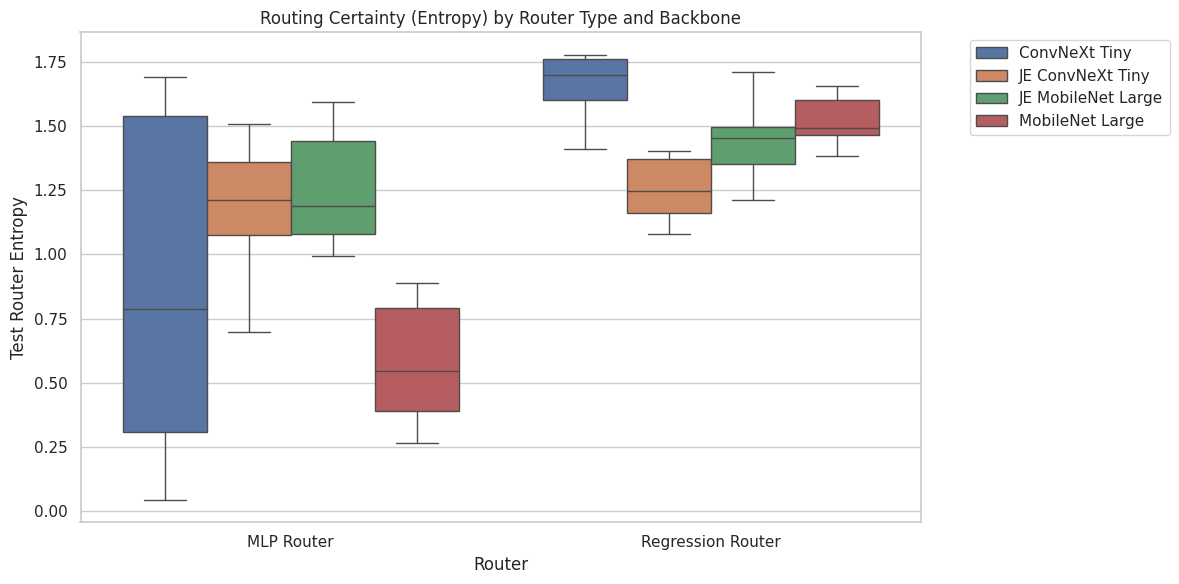

In [134]:
if {'Test Router Entropy', 'Backbone Group', 'Router'}.issubset(test_results_df.columns):
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=test_results_df, x='Router', y='Test Router Entropy', hue='Backbone Group')
    plt.title('Routing Certainty (Entropy) by Router Type and Backbone')
    plt.ylabel('Test Router Entropy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()